In [1]:
import logging
import os

logging.basicConfig(
    format='%(asctime)s - %(levelname)s - %(name)s: %(message)s',
    level=logging.INFO,
)
logger = logging.getLogger('finetune.ipynb')

DATA_FOLDER = os.path.join(os.path.expanduser('~'), 'data', 'ds000030')
PREPROCESSED_IMAGES_FOLDER = os.path.join(DATA_FOLDER, 'preprocessed')
LABELS_PATH = os.path.join(DATA_FOLDER, 'labels.csv')
LABELS = ['CONTROL', 'ADHD', 'BIPOLAR', 'SCHZ']

BATCH_SIZE = 3
NUM_THREADS = 3

I0000 00:00:1781090482.518728 3074891 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781090483.828020 3074891 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781090485.534073 3074891 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781090486.639589 3074891 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21590 MB me

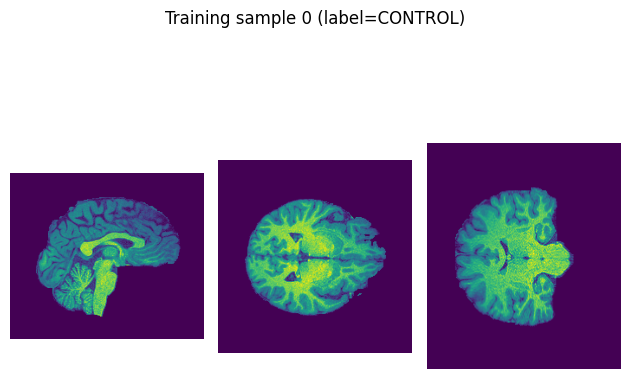

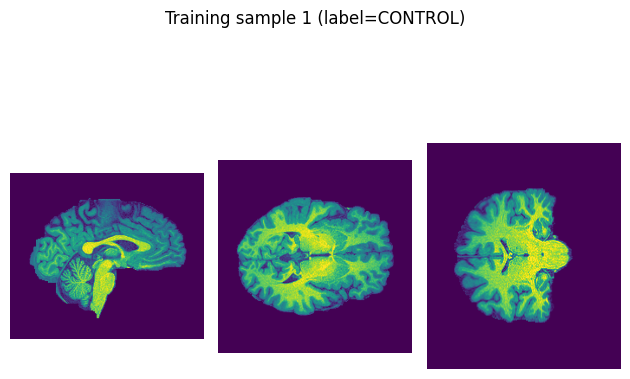

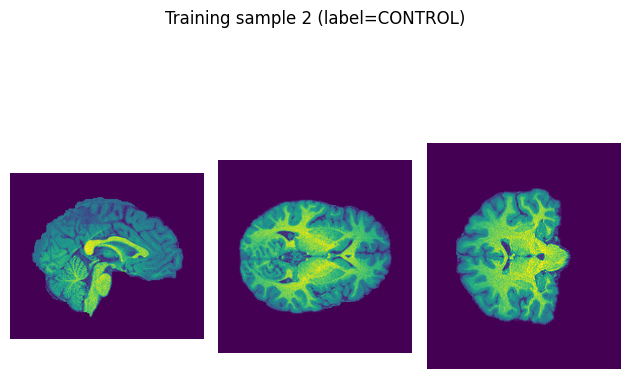

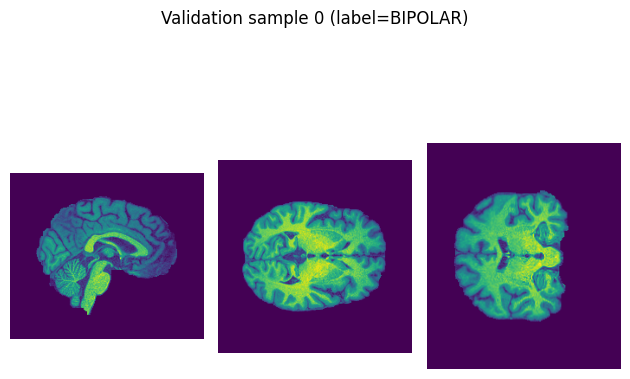

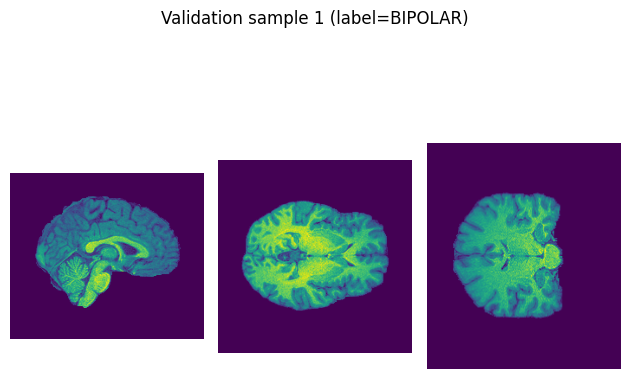

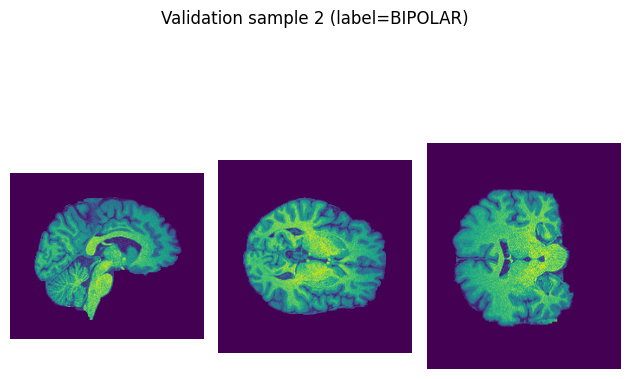

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from pyment.data import FastSurferDataset


# Manual onehot encoding
def target_encoder(value: str) -> np.ndarray:
    vector = np.zeros(len(LABELS))
    vector[LABELS.index(value)] = 1

    return vector


dataset = FastSurferDataset.from_paths(
    images_path=PREPROCESSED_IMAGES_FOLDER,
    labels_path=LABELS_PATH,
    target='diagnosis',
    target_encoder=target_encoder,
    class_weights='balanced',
)
train, validation = dataset.random_split(training_fraction=0.8)

train_generator = train.to_tensorflow_generator(
    batch_size=BATCH_SIZE, num_threads=NUM_THREADS, shuffle=True
)
validation_generator = validation.to_tensorflow_generator(
    batch_size=BATCH_SIZE, num_threads=NUM_THREADS, shuffle=False
)

logger.info('Training on %d samples', len(train))
logger.info('Validating on %d samples', len(validation))

for name, generator in [
    ('Training', train_generator),
    ('Validation', validation_generator),
]:
    for X, y in generator:
        for i in range(BATCH_SIZE):
            image = X[i].numpy()
            fig, ax = plt.subplots(1, 3)

            for dim in range(3):
                ax[dim].imshow(
                    np.take(image, indices=image.shape[dim] // 2, axis=dim)
                )
                ax[dim].axis('off')

            label = LABELS[np.argmax(y[i].numpy())]
            fig.suptitle(f'{name} sample {i} (label={label})')

            plt.tight_layout()
            plt.show()
        break

In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2

from pyment.models.sfcn import MultiTaskSFCN

backbone = MultiTaskSFCN(
    weights='multi-2025', regularizer=l2(1e-3), dropout=0.3
)
bottleneck = backbone.get_layer('SFCNMulti_dropout')
head = Dense(len(LABELS), activation='softmax')(bottleneck.output)

model = Model(backbone.input, head)

model.compile(
    loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']
)
model.fit(train_generator, validation_data=validation_generator, epochs=10)

Epoch 1/10


I0000 00:00:1781090492.749574 3075036 service.cc:153] XLA service 0x7955e003d680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781090492.749602 3075036 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781090493.084196 3075036 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781090493.461138 3075036 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781090493.524759 3075036 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6560__.84
E0000 00:00:1781090494.480162 3075036 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781090495.560105 3075036 cuda_timer.cc:87] Delay kernel timed out: measur

 1/71 ━━━━━━━━━━━━━━━━━━━━ 23:52 20s/step - accuracy: 0.3333 - loss: 2.0131

I0000 00:00:1781090510.832883 3075036 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.4045 - loss: 2.6205

I0000 00:00:1781090524.215842 3075041 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6560__.84
E0000 00:00:1781090525.150462 3075041 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781090526.018069 3075041 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781090526.425287 3075041 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


71/71 ━━━━━━━━━━━━━━━━━━━━ 49s 411ms/step - accuracy: 0.4245 - loss: 2.4058 - val_accuracy: 0.0000e+00 - val_loss: 5.6202
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 202ms/step - accuracy: 0.4575 - loss: 2.0436 - val_accuracy: 0.0000e+00 - val_loss: 6.2620
Epoch 3/10
 5/71 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.2556 - loss: 1.8303